In [1]:
import pandas as pd
import bz2
import re

# ----------------------------
# 1. Read Dataset
# ----------------------------
def read_bz2(path, sample_size=None, seed=42):
    """Read fastText sentiment data into DataFrame, optional sampling."""
    data = []
    with bz2.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(" ", 1)
            if len(parts) == 2:
                label, text = parts
                label = 1 if label == "__label__2" else 0  # 1 = positive, 0 = negative
                data.append((label, text))
    df = pd.DataFrame(data, columns=["label", "text"])
    if sample_size:
        df = df.sample(sample_size, random_state=seed)
    return df.reset_index(drop=True)

train_df = read_bz2("/content/train.ft.txt.bz2", sample_size=200000)
test_df  = read_bz2("/content/test.ft.txt.bz2", sample_size=20000)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())

# ----------------------------
# 2. Fast Text Cleaning
# ----------------------------
def fast_clean(series: pd.Series) -> pd.Series:
    """Vectorized fast preprocessing: lowercase + regex cleanup."""
    series = series.str.lower()
    series = series.str.replace(r"http\S+|www\S+", " URL ", regex=True)
    series = series.str.replace(r"[^a-z\s]", " ", regex=True)
    return series

train_df["clean_text"] = fast_clean(train_df["text"])
test_df["clean_text"]  = fast_clean(test_df["text"])

# ----------------------------
# 3. Save for Reuse
# ----------------------------
train_df.to_parquet("/content/train_cleaned_sample.parquet", index=False)
test_df.to_parquet("/content/test_cleaned_sample.parquet", index=False)

print("Cleaning complete. Columns available:")
print(train_df.columns)


Train shape: (200000, 2)
Test shape: (20000, 2)
   label                                               text
0      0  Expensive Junk: This product consists of a pie...
1      0  Toast too dark: Even on the lowest setting, th...
2      1  Excellent imagery...dumbed down story: I enjoy...
3      0  Are we pretending everyone is married?: The au...
4      0  Not worth your time: Might as well just use a ...
Cleaning complete. Columns available:
Index(['label', 'text', 'clean_text'], dtype='object')


TF-IDF matrix shapes: (160000, 20000) (40000, 20000) (20000, 20000)
Validation Accuracy: 0.886275

Classification Report:
               precision    recall  f1-score   support

           0      0.887     0.886     0.886     19996
           1      0.886     0.887     0.886     20004

    accuracy                          0.886     40000
   macro avg      0.886     0.886     0.886     40000
weighted avg      0.886     0.886     0.886     40000



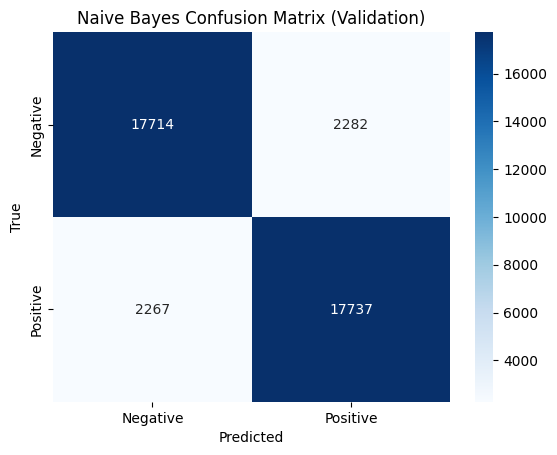

Test Accuracy (approx): 0.88725


In [2]:
# ============================
# TF-IDF + Naive Bayes
# ============================

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# 1. Load Preprocessed Sample
# ----------------------------
train_df = pd.read_parquet("/content/train_cleaned_sample.parquet")
test_df  = pd.read_parquet("/content/test_cleaned_sample.parquet")

X_text = train_df["clean_text"]
y = train_df["label"]

# ----------------------------
# 2. Train/Validation Split
# ----------------------------
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# 3. TF-IDF Vectorizer
# ----------------------------
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=20000,      # reduced to fit Colab RAM
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_val_tfidf   = vectorizer.transform(X_val_text)
X_test_tfidf  = vectorizer.transform(test_df["clean_text"])

print("TF-IDF matrix shapes:",
      X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape)

# ----------------------------
# 4. Naive Bayes Model
# ----------------------------
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# ----------------------------
# 5. Validation Evaluation
# ----------------------------
y_val_pred = nb.predict(X_val_tfidf)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred, digits=3))

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.title("Naive Bayes Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ----------------------------
# 6. Test Predictions
# ----------------------------
y_test_pred = nb.predict(X_test_tfidf)
print("Test Accuracy (approx):", accuracy_score(test_df["label"], y_test_pred))


In [6]:
# ============================
#  DistilBERT
# ============================

!pip install -q transformers datasets

import pandas as pd
import torch
from datasets import Dataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import os

# ----------------------------
# 1. Disable wandb
# ----------------------------
os.environ["WANDB_DISABLED"] = "true"

# ----------------------------
# 2. Load Sampled Clean Data
# ----------------------------
train_df = pd.read_parquet("/content/train_cleaned_sample.parquet")
test_df  = pd.read_parquet("/content/test_cleaned_sample.parquet")

# Reduce dataset size for speed
train_df = train_df.sample(20000, random_state=42)   # 20k train
test_df  = test_df.sample(2000, random_state=42)     # 2k test

train_dataset = Dataset.from_pandas(train_df[["clean_text", "label"]])
test_dataset  = Dataset.from_pandas(test_df[["clean_text", "label"]])

# ----------------------------
# 3. Tokenizer
# ----------------------------
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch["clean_text"],
                     padding="max_length",
                     truncation=True,
                     max_length=64)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# ----------------------------
# 4. Model
# ----------------------------
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# ----------------------------
# 5. Metrics Function
# ----------------------------
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

# ----------------------------
# 6. Training
# ----------------------------
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    save_total_limit=1,
    overwrite_output_dir=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

# ----------------------------
# 7. Manual Evaluation
# ----------------------------
results = trainer.evaluate(eval_dataset=test_dataset)
print("Evaluation results:", results)


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-2778344442.py:81: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
100,0.425400
200,0.286900
300,0.265600
400,0.260800
500,0.222400


Step,Training Loss
100,0.425400
200,0.286900
300,0.265600
400,0.260800
500,0.222400
600,0.228400


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Evaluation results: {'eval_loss': 0.21537652611732483, 'eval_accuracy': 0.9135, 'eval_f1': 0.9135188565367485, 'eval_precision': 0.9136149452951201, 'eval_recall': 0.9135, 'eval_runtime': 146.8268, 'eval_samples_per_second': 13.621, 'eval_steps_per_second': 0.429, 'epoch': 1.0}


In [7]:
# ============================
# Inference with DistilBERT
# ============================

from transformers import pipeline

# Load trained model + tokenizer from trainer
inference_pipe = pipeline(
    "text-classification",
    model=trainer.model,
    tokenizer=tokenizer,
    return_all_scores=True
)

def predict_sentiment(text):
    preds = inference_pipe(text)[0]
    label_map = {"LABEL_0": "Negative", "LABEL_1": "Positive"}
    for p in preds:
        p["label"] = label_map[p["label"]]
    return preds

# ----------------------------
# Test Examples
# ----------------------------
examples = [
    "This product is amazing, I absolutely loved it!",
    "Worst purchase I have ever made.",
    "It's okay, not the best but not terrible either."
]

for text in examples:
    print(f"\nText: {text}")
    preds = predict_sentiment(text)
    for p in preds:
        print(f"  {p['label']}: {p['score']:.3f}")


Device set to use cpu
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(



Text: This product is amazing, I absolutely loved it!
  Negative: 0.018
  Positive: 0.982

Text: Worst purchase I have ever made.
  Negative: 0.981
  Positive: 0.019

Text: It's okay, not the best but not terrible either.
  Negative: 0.634
  Positive: 0.366


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

    Negative      0.904     0.917     0.911       960
    Positive      0.922     0.911     0.916      1040

    accuracy                          0.913      2000
   macro avg      0.913     0.914     0.913      2000
weighted avg      0.914     0.913     0.914      2000



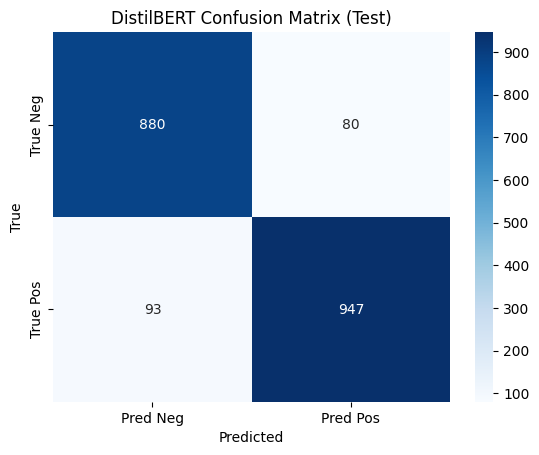


Top 10 False Negatives (model very confident it's Negative):


,text,p_neg,p_pos
419,replaced by nesco we bought this in and...,0.977379,0.022621
663,bad sub titles for most europeans the and ...,0.975879,0.024121
495,season i bought this item from amazon com ...,0.972255,0.027745
1157,not yer mama s lesbian fiction lesbian fic...,0.971897,0.028103
1911,fdr s folly content wise fdr s folly is much...,0.971860,0.028140
121,chill out i m not a big english writing jargo...,0.970177,0.029823
715,nix those motherboard ports i was having pro...,0.970145,0.029855
1441,just fell short for me i must say i was looki...,0.969868,0.030132
371,headbanging stuff considering the direction t...,0.969799,0.030201
1305,funny but slim bill is a funny guy but if you...,0.968356,0.031644



Top 10 False Positives (model very confident it's Positive):


,text,p_neg,p_pos
217,i ve seen them live at my high school ye...,0.014443,0.985557
1080,natanya ross is in it honestly the only reas...,0.018405,0.981595
1067,old time fun this was a hilarious movie ever...,0.019299,0.980701
124,blues highway book arrived in good condition ...,0.022101,0.977899
1114,will s best cd overall this was a pretty goo...,0.024348,0.975652
1442,ok album this album is real good my favorite ...,0.024943,0.975057
1125,worth the read the book is worth reading sinc...,0.027574,0.972426
1677,photo never recieved the lens so i just went...,0.037548,0.962452
275,fine but high defect rate the saitek eclips...,0.038882,0.961118
79,this dvd made me cry try reading our babies ...,0.047841,0.952159



Saved:
  /content/top_false_negatives.csv
  /content/top_false_positives.csv
  /content/all_errors.csv


In [8]:
# ============================
# Error Analysis (DistilBERT)
# ============================

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Predict on test set
pred_out = trainer.predict(test_dataset)
y_true = pred_out.label_ids
logits = pred_out.predictions
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_pred = probs.argmax(axis=1)

# 2) Confusion Matrix + Report
print(classification_report(y_true, y_pred, digits=3, target_names=["Negative","Positive"]))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Neg","Pred Pos"],
            yticklabels=["True Neg","True Pos"])
plt.title("DistilBERT Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 3) Build analysis DataFrame
analysis_df = pd.DataFrame({
    "text": test_df["clean_text"].reset_index(drop=True),
    "true": y_true,
    "pred": y_pred,
    "p_neg": probs[:,0],
    "p_pos": probs[:,1]
})
analysis_df["correct"] = (analysis_df["true"] == analysis_df["pred"])

# 4) High-confidence errors
fn = analysis_df[(analysis_df.true==1) & (analysis_df.pred==0)].copy()
fp = analysis_df[(analysis_df.true==0) & (analysis_df.pred==1)].copy()
fn["conf_wrong"] = fn["p_neg"]  # model’s confidence in the wrong class
fp["conf_wrong"] = fp["p_pos"]

top_fn = fn.sort_values("conf_wrong", ascending=False).head(20)
top_fp = fp.sort_values("conf_wrong", ascending=False).head(20)

print("\nTop 10 False Negatives (model very confident it's Negative):")
display(top_fn[["text","p_neg","p_pos"]].head(10))

print("\nTop 10 False Positives (model very confident it's Positive):")
display(top_fp[["text","p_neg","p_pos"]].head(10))

# 5) Save for deeper review
top_fn.to_csv("/content/top_false_negatives.csv", index=False)
top_fp.to_csv("/content/top_false_positives.csv", index=False)
full_errors = analysis_df[~analysis_df["correct"]]
full_errors.to_csv("/content/all_errors.csv", index=False)

print("\nSaved:")
print("  /content/top_false_negatives.csv")
print("  /content/top_false_positives.csv")
print("  /content/all_errors.csv")


Results Summary:


,Model,Accuracy,F1
0,Naive Bayes (TF-IDF),0.8860,0.8860
1,DistilBERT,0.9135,0.9135


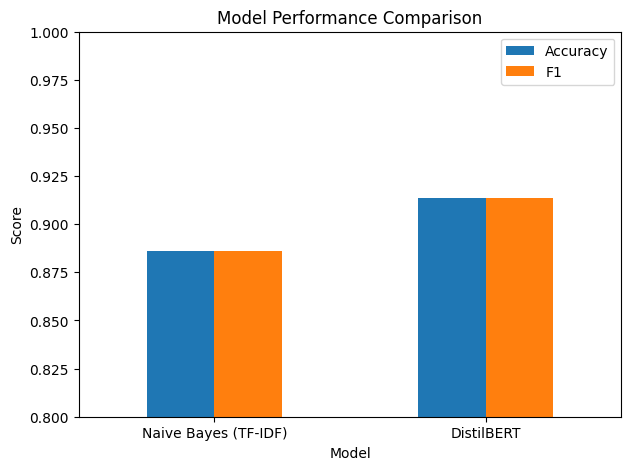

In [9]:
# ============================
# Results Summary
# ============================

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1. Collect Results
# ----------------------------
nb_acc = 0.886
nb_f1  = 0.886

bert_acc = 0.9135
bert_f1  = 0.9135

results = pd.DataFrame({
    "Model": ["Naive Bayes (TF-IDF)", "DistilBERT"],
    "Accuracy": [nb_acc, bert_acc],
    "F1": [nb_f1, bert_f1]
})

print("Results Summary:")
display(results)

# ----------------------------
# 2. Plot Comparison
# ----------------------------
results.set_index("Model")[["Accuracy","F1"]].plot.bar(
    rot=0, figsize=(7,5), ylim=(0.8,1.0), legend=True
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()


In [10]:
# ============================
#  Save & Export Model
# ============================

import os

# ----------------------------
# 1. Save model + tokenizer locally
# ----------------------------
save_dir = "/content/distilbert_sentiment"

trainer.save_model(save_dir)         # saves model
tokenizer.save_pretrained(save_dir)  # saves tokenizer

print(f"Model and tokenizer saved to: {save_dir}")

# ----------------------------
# 2. Zip for download
# ----------------------------
!zip -r distilbert_sentiment.zip /content/distilbert_sentiment

print("Zipped model: distilbert_sentiment.zip")

# ----------------------------
# 3. Load back
# ----------------------------
from transformers import pipeline, DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(save_dir)
tokenizer = tokenizer.from_pretrained(save_dir)

inference_pipe = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    top_k=None
)

print("Reloaded model works. Example:")
print(inference_pipe("I really love this product!"))


Model and tokenizer saved to: /content/distilbert_sentiment
  adding: content/distilbert_sentiment/ (stored 0%)
  adding: content/distilbert_sentiment/model.safetensors (deflated 8%)
  adding: content/distilbert_sentiment/training_args.bin (deflated 53%)
  adding: content/distilbert_sentiment/tokenizer_config.json (deflated 75%)
  adding: content/distilbert_sentiment/config.json (deflated 45%)
  adding: content/distilbert_sentiment/special_tokens_map.json (deflated 42%)
  adding: content/distilbert_sentiment/tokenizer.json (deflated 71%)
  adding: content/distilbert_sentiment/vocab.txt (deflated 53%)


Device set to use cpu


Zipped model: distilbert_sentiment.zip
Reloaded model works. Example:
[[{'label': 'LABEL_1', 'score': 0.9724826216697693}, {'label': 'LABEL_0', 'score': 0.02751738391816616}]]


In [12]:
# ============================
# Gradio App
# ============================

!pip install -q gradio

import gradio as gr
from transformers import pipeline, DistilBertForSequenceClassification, DistilBertTokenizerFast

# Load the saved model from Block 8
model_path = "/content/distilbert_sentiment"
model = DistilBertForSequenceClassification.from_pretrained(model_path)
tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)

pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, top_k=None)

# Prediction function with explicit label mapping
def predict_sentiment(text):
    preds = pipe(text)[0]
    label_map = {"LABEL_0": "Negative", "LABEL_1": "Positive"}
    return {label_map[p["label"]]: float(p["score"]) for p in preds}

# Gradio interface
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Type a review here..."),
    outputs="label",
    title="Sentiment Classifier (DistilBERT)",
    description="Enter text to classify sentiment as Positive or Negative"
)

demo.launch(share=True)


Device set to use cpu


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f94d0b7c06cc6f60b8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [13]:
%%writefile app.py
import gradio as gr
from transformers import pipeline, DistilBertForSequenceClassification, DistilBertTokenizerFast

# Load model + tokenizer (expects distilbert_sentiment/ folder in same repo)
model_path = "./distilbert_sentiment"
model = DistilBertForSequenceClassification.from_pretrained(model_path)
tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)

pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, top_k=None)

def predict_sentiment(text):
    preds = pipe(text)[0]
    label_map = {"LABEL_0": "Negative", "LABEL_1": "Positive"}
    return {label_map[p["label"]]: float(p["score"]) for p in preds}

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Type a review here..."),
    outputs="label",
    title="Sentiment Classifier (DistilBERT)",
    description="Enter text to classify sentiment as Positive or Negative"
)

if __name__ == "__main__":
    demo.launch()


Writing app.py
